**Jack Dai**

CS 251/2: Data Analysis and Visualization

Spring 2026

Project 3: Clustering


In [7]:
import numpy as np
import matplotlib.pyplot as plt

import kmeans

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5)


# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 2: Image Quantization

In this task, you will apply K-means to one image and to quantize it (_this is a version of the image with fewer colors, and fewer colors allows image formats to compress the images_). The idea is that you will find $k$ RGB color centroids in the image, then replace each pixel in the image with the nearest centroid. The resulting picture will use only $k$ colors to represent it. You can also think of this as doing a simple image region segmentation: regions with similar colors will belong to the same cluster. It also makes some cool retro effects!


### 2a. Load in frog image

1. Use the imported `imread` method below to load in the `frog.jpg` image.
2. Use `plt.imshow` to display it in the notebook below. Turn off plot ticks!


In [8]:
from matplotlib.image import imread

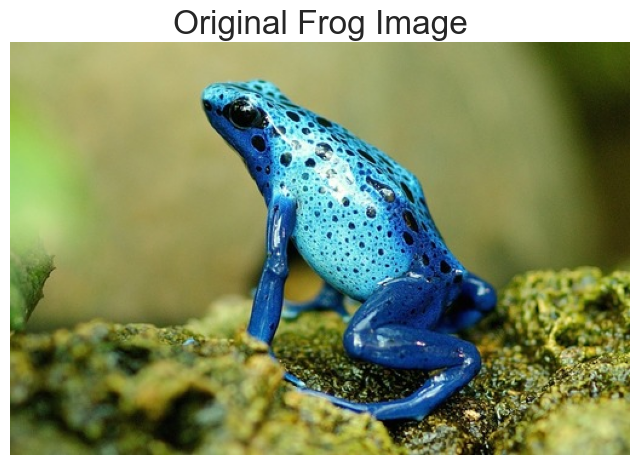

In [9]:
frog = imread('data/frog.jpg')
plt.figure(figsize=(8, 6))
plt.imshow(frog)
plt.title('Original Frog Image')
plt.xticks([])
plt.yticks([])
plt.show()

### 2b. Preprocess image

In the two cells below:

1. Fill in the function below to collapse (flatten) the 2D image into a big 1D vector of RGB values. For example, for the frog image, your function should take the shape `(num_rows, num_cols, rgb)` and convert it to `(num_rows*num_cols, rgb)`.
2. Reshape the frog image from `(num_rows, num_cols, rgb)` and convert it to `(num_rows*num_cols, rgb)`.


In [10]:
def flatten(img):
    '''Flattens `img` to N 1D vectors.
    For example, for an RGB image, `(num_rows, num_cols, rgb)` -> `(num_rows*num_cols, rgb)`.

    Parameters:
    -----------
    img: ndarray. shape=(num_rows, num_cols, rgb)

    Returns:
    -----------
    Flattened `img`. ndarray. shape=(num_rows*num_cols, rgb)
    '''
    return img.reshape(-1, img.shape[-1])

In [11]:
frog_flat = flatten(frog)
frog_flat.shape

(174592, 3)

#### Test frog image shape


In [12]:
print(f'The shape of your frog image after flattening is\n{frog_flat.shape}')
print('and it should be\n(174592, 3)')

The shape of your frog image after flattening is
(174592, 3)
and it should be
(174592, 3)


### 2c. Cluster RGB values in image

1. Run K-means on the flattened frog image. Cluster the image so that the quantized/clustered image will have only 3 colors.
2. Implement `replace_color_with_centroid`: replace every pixel in the image with the nearest centroid RGB value.
3. Quantize the image by running `replace_color_with_centroid`.


In [13]:
np.random.seed(0)
frog_km = kmeans.KMeans(frog_flat.astype(float))
frog_km.cluster_batch(k=3, n_iter=10)

K-means ran for 11 iterations
K-means ran for 37 iterations
K-means ran for 10 iterations
K-means ran for 22 iterations
K-means ran for 9 iterations
K-means ran for 7 iterations
K-means ran for 9 iterations
K-means ran for 10 iterations
K-means ran for 21 iterations
K-means ran for 9 iterations


In [14]:
frog_km.replace_color_with_centroid()
frog_quant_flat = frog_km.get_data()

### 2d. Postprocessing and visualization

Reshape the quantized image data back to its original dimensions and cast the ndarray so that it stores ints.

Plot the quantized image below.


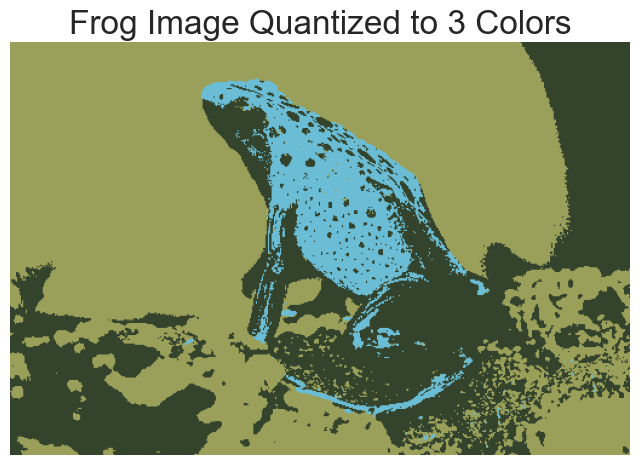

In [15]:
frog_quant = np.clip(frog_quant_flat.reshape(frog.shape), 0, 255).astype(np.uint8)
plt.figure(figsize=(8, 6))
plt.imshow(frog_quant)
plt.title('Frog Image Quantized to 3 Colors')
plt.xticks([])
plt.yticks([])
plt.show()

### 2e. Run K-means and quantize an image of your choice

Smaller images run a lot faster.


In [16]:
my_img = imread('data/world_map_small.png')
my_img_flat = flatten(my_img)

K-means ran for 2 iterations
K-means ran for 4 iterations
K-means ran for 2 iterations
K-means ran for 2 iterations
K-means ran for 5 iterations
K-means ran for 2 iterations
K-means ran for 3 iterations
K-means ran for 3 iterations
K-means ran for 2 iterations
K-means ran for 3 iterations


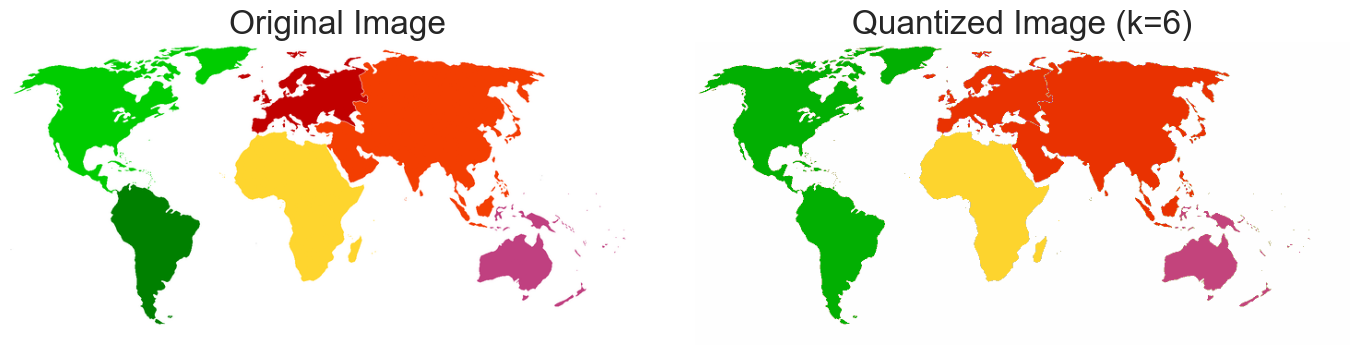

In [17]:
np.random.seed(0)
my_km = kmeans.KMeans(my_img_flat.astype(float))
my_km.cluster_batch(k=6, n_iter=10)
my_km.replace_color_with_centroid()
my_quant = np.clip(my_km.get_data().reshape(my_img.shape), 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(my_img)
axes[0].set_title('Original Image')
axes[1].imshow(my_quant)
axes[1].set_title('Quantized Image (k=6)')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Task 3: Image region segmentation

The goal is to apply K-means to a colorized map of world continents (sans Antarctica) and segment out each continent in its own image.


### 3a. Load in and visualize world map

Load and view `world_map_small.png` in the cell below using matplotlib.

_As with the images in the previous task, turn off ticks and any other visual clutter._


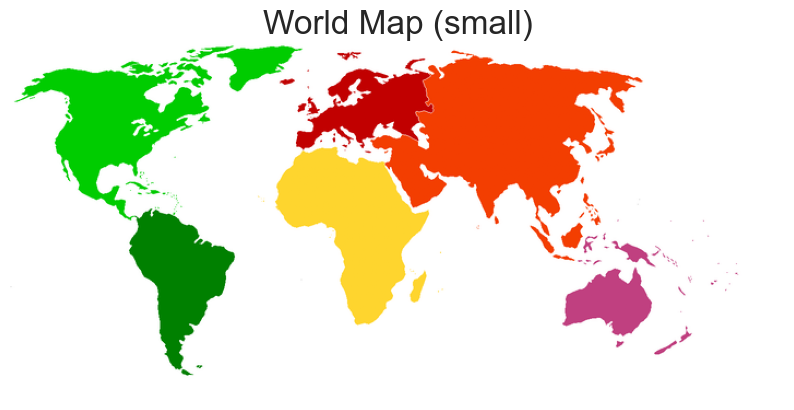

In [18]:
world_map = imread('data/world_map_small.png')
plt.figure(figsize=(10, 5))
plt.imshow(world_map)
plt.title('World Map (small)')
plt.xticks([])
plt.yticks([])
plt.show()

### 3b. Implement and test the `segment_cluster` method in the `Kmeans` class


#### Test: `segment_cluster`

Run the following test multiple times and make sure it always looks correct.


In [19]:
test_data = np.vstack([np.zeros([1, 5]), np.ones([1, 5]), 3*np.ones([1, 5]), 2*np.ones([1, 5]), np.ones([1, 5])])
print('Test data looks like:')
print(test_data)
test_km = kmeans.KMeans(test_data)
test_km.cluster(k=2)
test_km.replace_color_with_centroid()
seg_data = test_km.segment_cluster(k=0)
print('There should be only 0s in following rows:', np.flatnonzero(test_km.get_data_centroid_labels()))
print(seg_data)

Test data looks like:
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [3. 3. 3. 3. 3.]
 [2. 2. 2. 2. 2.]
 [1. 1. 1. 1. 1.]]
K-means ran for 2 iterations
There should be only 0s in following rows: [0 1 4]
[[0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0. ]
 [2.5 2.5 2.5 2.5 2.5]
 [2.5 2.5 2.5 2.5 2.5]
 [0.  0.  0.  0.  0. ]]


### 3c. Use K-means to segment the world map image

Use K-means and your segmentation method to show 6 separate images below, each with only one colored continent. You should select a number of clusters that allows you to reliably segment the continents.

**Notes:**

- It is fine if North and South America appear in the same plot (in which case you only need to generate 5 images).
- It is fine if faint outlines of other continents are included in a segment continent in solid color.
- Before you segment, it might be helpful to view your quantized image to visualize the clusters.
- The segmented color of each continent might be slightly different from the original based on what the centroids are.


K-means ran for 2 iterations
K-means ran for 4 iterations
K-means ran for 2 iterations
K-means ran for 2 iterations
K-means ran for 5 iterations
K-means ran for 2 iterations
K-means ran for 3 iterations
K-means ran for 3 iterations
K-means ran for 2 iterations
K-means ran for 3 iterations
K-means ran for 3 iterations
K-means ran for 4 iterations
K-means ran for 2 iterations
K-means ran for 4 iterations
K-means ran for 3 iterations
K-means ran for 3 iterations
K-means ran for 2 iterations
K-means ran for 3 iterations
K-means ran for 2 iterations
K-means ran for 2 iterations


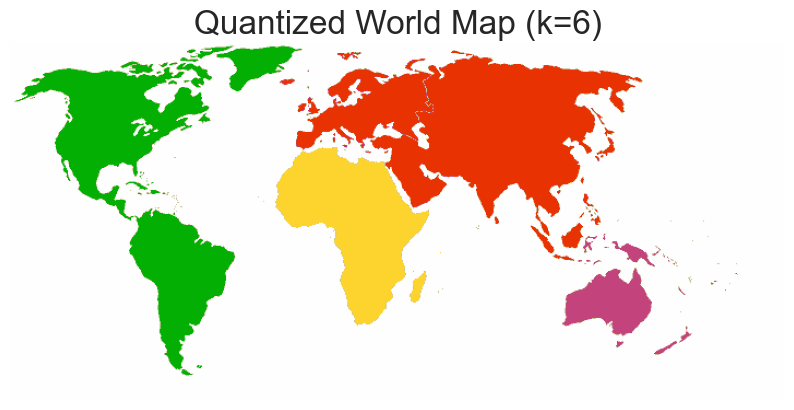

In [20]:
np.random.seed(0)  # KEEP ME

world_flat = flatten(world_map)
world_km = kmeans.KMeans(world_flat.astype(float))
world_km.cluster_batch(k=6, n_iter=20)
world_km.replace_color_with_centroid()
world_quant = np.clip(world_km.get_data().reshape(world_map.shape), 0, 1)

plt.figure(figsize=(10, 5))
plt.imshow(world_quant)
plt.title('Quantized World Map (k=6)')
plt.xticks([])
plt.yticks([])
plt.show()

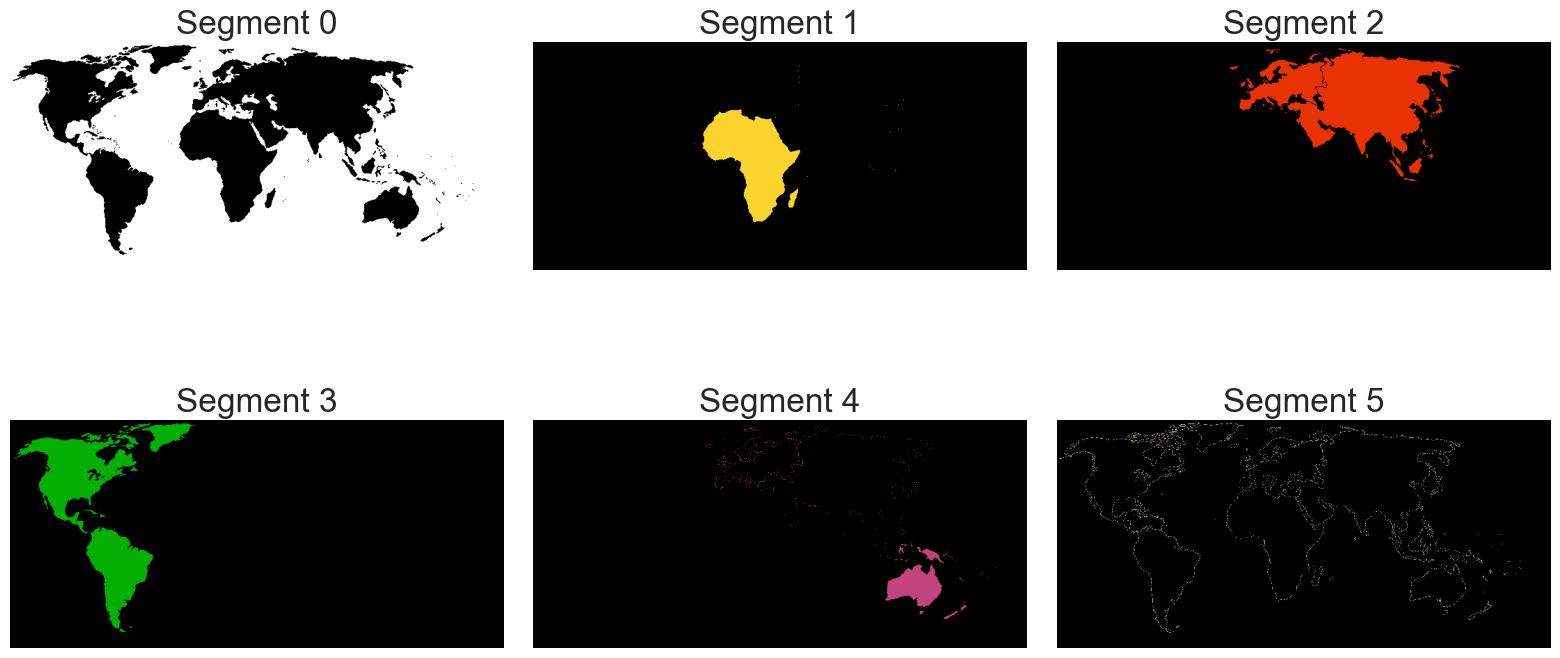

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for cid in range(6):
    seg_flat = world_km.segment_cluster(k=cid)
    seg_img = np.clip(seg_flat.reshape(world_map.shape), 0, 1)
    axes[cid].imshow(seg_img)
    axes[cid].set_title(f'Segment {cid}')
    axes[cid].set_xticks([])
    axes[cid].set_yticks([])
plt.tight_layout()
plt.show()